# 🤖 Fine-tuning BART-base pour la QA Médicale
**Pipeline complet** : Chargement CSV → Split → Tokenisation → Fine-tuning → Évaluation (ROUGE + BERTScore + Compression)

> GPU : NVIDIA T4 (Kaggle) | Modèle : `facebook/bart-base` | Durée estimée : ~2-3h

## Cellule 1 — Installation des dépendances

In [11]:
# ============================================================
# CELLULE 1 — Installation des dépendances
# ============================================================

import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.40.0",
    "datasets==2.19.0",
    "evaluate==0.4.1",
    "rouge-score==0.1.2",
    "bert-score==0.3.13",
    "seaborn",
    "accelerate>=0.30.0",   # ← version corrigée (clear_device_cache dispo depuis 0.30)
    "peft>=0.10.0",          # ← aligner peft avec accelerate
])

print("✅ Installation terminée")
print("⚠️  Restart kernel obligatoire → Run > Restart & Clear Output")

✅ Installation terminée
⚠️  Restart kernel obligatoire → Run > Restart & Clear Output


## Cellule 2 — Configuration centrale (tous les hyperparamètres ici)

In [12]:
# ============================================================
# CELLULE 2 — Configuration centrale
# ============================================================

from dataclasses import dataclass
import os

@dataclass
class Config:
    # ── Données ──────────────────────────────────────────
    DATA_PATH     : str   = '/kaggle/input/datasets/mdamineelarbani/qa-datset-prombt-engineering/QA_dataset.csv'
    OUTPUT_DIR    : str   = '/kaggle/working/bart_medical'
    LOG_DIR       : str   = '/kaggle/working/logs'

    # ── Colonnes du CSV ──────────────────────────────────
    # L'input du modèle = concaténation de 'question' + 'note'
    # Le target = 'answer'
    QUESTION_COL  : str   = 'question'
    NOTE_COL      : str   = 'note'      # contexte clinique (optionnel mais utile)
    TARGET_COL    : str   = 'answer'

    # Séparateur entre question et note dans l'input
    # BART a appris des séparateurs spéciaux — </s> est son token natif
    SEP_TOKEN     : str   = ' </s> '

    # ── Split train/val/test ─────────────────────────────
    TEST_SIZE     : float = 0.10
    VAL_SIZE      : float = 0.10
    RANDOM_SEED   : int   = 42

    # ── Modèle ───────────────────────────────────────────
    MODEL_NAME    : str   = 'facebook/bart-base'
    # Alternative médicale : 'GanjinZero/biobart-base'

    # ── Tokenisation ─────────────────────────────────────
    # MAX_SOURCE_LEN couvre question + séparateur + note
    MAX_SOURCE_LEN: int   = 512
    MAX_TARGET_LEN: int   = 128

    # ── Entraînement ─────────────────────────────────────
    NUM_EPOCHS    : int   = 4
    BATCH_SIZE    : int   = 8
    GRAD_ACCUM    : int   = 2      # batch effectif = 16
    LR            : float = 3e-5
    WEIGHT_DECAY  : float = 0.01
    WARMUP_RATIO  : float = 0.06
    FP16          : bool  = True
    EVAL_STEPS    : int   = 500
    SAVE_STEPS    : int   = 500
    SAVE_TOTAL    : int   = 2

    # ── Génération ───────────────────────────────────────
    GEN_MAX_LEN    : int   = 128
    GEN_MIN_LEN    : int   = 20
    NUM_BEAMS      : int   = 4
    LENGTH_PENALTY : float = 1.0
    NO_REPEAT_NGRAM: int   = 3

CFG = Config()
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
os.makedirs(CFG.LOG_DIR,    exist_ok=True)
print('✅ Configuration chargée')
print(f'   Input  : "{CFG.QUESTION_COL}" + SEP + "{CFG.NOTE_COL}"')
print(f'   Output : "{CFG.TARGET_COL}"')
print(f'   Modèle : {CFG.MODEL_NAME}')


✅ Configuration chargée
   Input  : "question" + SEP + "note"
   Output : "answer"
   Modèle : facebook/bart-base


## Cellule 3 — Chargement, nettoyage et split des données

📂 Dataset brut : 1,500 lignes
   Colonnes     : ['Unnamed: 0', 'patient_id', 'note', 'question', 'answer', 'task']
✅ Après nettoyage : 1,500 lignes

=== Longueurs (mots) ===
       src_len  tgt_len
count   1500.0   1500.0
mean     307.6     79.9
std       87.2     27.1
min      143.0     15.0
25%      246.0     62.0
50%      297.0     78.0
75%      355.0     95.0
max      811.0    234.0


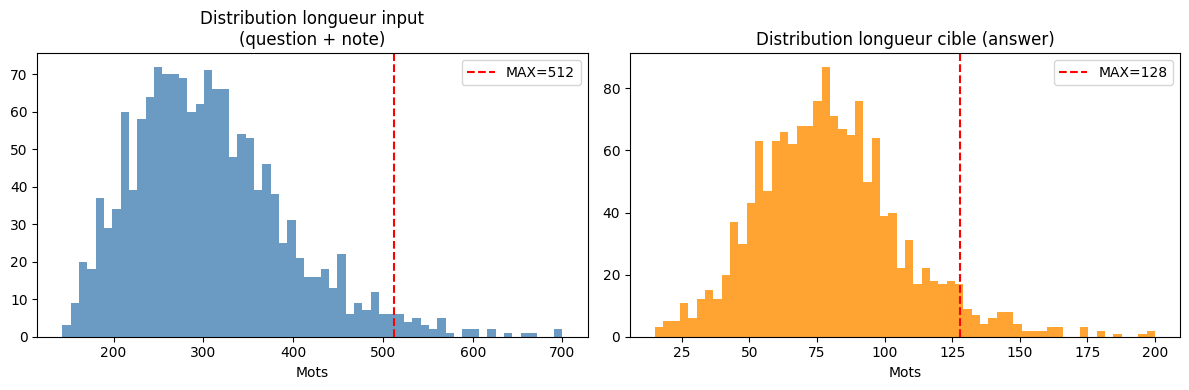


⚠️  Inputs tronqués  (>512 mots) : 2.6%
⚠️  Targets tronqués (>128 mots) : 4.7%

=== Split final ===
  Train      : 1,200 (80.0%)
  Validation : 150   (10.0%)
  Test       : 150   (10.0%)

=== Exemple d'une paire d'entraînement ===
INPUT  : What key clinical information and diagnosis were revealed through genetic testing in this discharge summary? </s> Hospital Course Summary: Admission Date: 6th Dec 2017 Discharge Date: N/A Chief Complaint: Ventricular tachyarrhythmia History of Present Illness: The patient was admitted due to witness...
TARGET : Comprehensive molecular-genetic testing revealed a missense variant in the Ryanodine receptor 2 (RyR2) gene, which is a possible disease-causing mutation associated with catecholaminergic polymorphic 

✅ Splits sauvegardés


In [13]:
# ============================================================
# CELLULE 3 — Chargement CSV + nettoyage + split 80/10/10
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv(CFG.DATA_PATH)
print(f'📂 Dataset brut : {df.shape[0]:,} lignes')
print(f'   Colonnes     : {df.columns.tolist()}')

# ── Nettoyage ────────────────────────────────────────────
required = [CFG.QUESTION_COL, CFG.TARGET_COL]
if CFG.NOTE_COL in df.columns:
    required.append(CFG.NOTE_COL)

df = df.dropna(subset=required)
for col in required:
    df[col] = df[col].astype(str).str.strip()

# Filtrer les lignes trop courtes
df = df[
    (df[CFG.QUESTION_COL].str.split().str.len() >= 3) &
    (df[CFG.TARGET_COL].str.split().str.len()   >= 5)
]
df = df.reset_index(drop=True)
print(f'✅ Après nettoyage : {df.shape[0]:,} lignes')

# ── Construire l'input : question </s> note ──────────────
# Si la colonne 'note' n'existe pas, on utilise uniquement la question
if CFG.NOTE_COL in df.columns:
    df['input_text'] = (
        df[CFG.QUESTION_COL] + CFG.SEP_TOKEN + df[CFG.NOTE_COL]
    )
else:
    df['input_text'] = df[CFG.QUESTION_COL]
    print('⚠️  Colonne note absente — input = question uniquement')

df['target_text'] = df[CFG.TARGET_COL]

# ── Statistiques longueurs ───────────────────────────────
df['src_len'] = df['input_text'].str.split().str.len()
df['tgt_len'] = df['target_text'].str.split().str.len()

print(f'\n=== Longueurs (mots) ===')
print(df[['src_len','tgt_len']].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['src_len'].clip(upper=700), bins=60, color='steelblue', alpha=0.8)
axes[0].axvline(CFG.MAX_SOURCE_LEN, color='red', linestyle='--',
                label=f'MAX={CFG.MAX_SOURCE_LEN}')
axes[0].set_title('Distribution longueur input\n(question + note)')
axes[0].set_xlabel('Mots'); axes[0].legend()

axes[1].hist(df['tgt_len'].clip(upper=200), bins=60, color='darkorange', alpha=0.8)
axes[1].axvline(CFG.MAX_TARGET_LEN, color='red', linestyle='--',
                label=f'MAX={CFG.MAX_TARGET_LEN}')
axes[1].set_title('Distribution longueur cible (answer)')
axes[1].set_xlabel('Mots'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/data_distribution.png', dpi=150)
plt.show()

pct_src = (df['src_len'] > CFG.MAX_SOURCE_LEN).mean() * 100
pct_tgt = (df['tgt_len'] > CFG.MAX_TARGET_LEN).mean() * 100
print(f'\n⚠️  Inputs tronqués  (>{CFG.MAX_SOURCE_LEN} mots) : {pct_src:.1f}%')
print(f'⚠️  Targets tronqués (>{CFG.MAX_TARGET_LEN} mots) : {pct_tgt:.1f}%')

# ── Split 80/10/10 stratifié ─────────────────────────────
stratify_col = df['task'] if 'task' in df.columns else None

df_train_val, df_test = train_test_split(
    df, test_size=CFG.TEST_SIZE,
    random_state=CFG.RANDOM_SEED, stratify=stratify_col
)
strat_val = df_train_val['task'] if 'task' in df_train_val.columns else None
df_train, df_val = train_test_split(
    df_train_val,
    test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE),
    random_state=CFG.RANDOM_SEED, stratify=strat_val
)

print(f'\n=== Split final ===')
print(f'  Train      : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Validation : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test       : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f}%)')

# Aperçu d'un exemple
print(f"\n=== Exemple d'une paire d'entraînement ===")
ex = df_train.iloc[0]
print(f'INPUT  : {ex["input_text"][:300]}...')
print(f'TARGET : {ex["target_text"][:200]}')

df_train.to_csv(f'{CFG.OUTPUT_DIR}/split_train.csv', index=False)
df_val.to_csv(f'{CFG.OUTPUT_DIR}/split_val.csv',     index=False)
df_test.to_csv(f'{CFG.OUTPUT_DIR}/split_test.csv',   index=False)
print('\n✅ Splits sauvegardés')


## Cellule 4 — Tokenisation et création des HuggingFace Datasets

In [14]:
# ============================================================
# CELLULE 4 — Tokenisation BART (compatible transformers 4.x)
#
# BUGS CORRIGÉS :
#   1. CFG.SOURCE_COL inexistant → remplacé par 'input_text' / 'target_text'
#      (colonnes déjà construites en cellule 3)
#   2. tokenizer.as_target_tokenizer() déprécié depuis transformers 4.x
#      → remplacé par le paramètre text_target=
# ============================================================

from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

print(f'🔄 Chargement tokenizer : {CFG.MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME)
print(f'✅ Tokenizer chargé — Vocab size: {tokenizer.vocab_size:,}')

def preprocess_function(examples):
    """
    Tokenise les paires (input_text → target_text) pour BART.
    Compatible transformers >= 4.0 (sans as_target_tokenizer).

    input_text  = question + </s> + note  (construit en cellule 3)
    target_text = answer

    Les tokens de padding dans les labels sont remplacés par -100
    pour être ignorés par la CrossEntropy loss.
    """
    # ── Tokeniser l'input (question + note) ──────────────
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=CFG.MAX_SOURCE_LEN,
        truncation=True,
        padding='max_length',
    )

    # ── Tokeniser le target (answer) ─────────────────────
    # text_target= est le remplacement moderne de as_target_tokenizer()
    labels = tokenizer(
        text_target=examples['target_text'],
        max_length=CFG.MAX_TARGET_LEN,
        truncation=True,
        padding='max_length',
    )

    # Remplacer pad_token_id par -100 dans les labels
    # → ces positions sont ignorées par la loss (pas pénalisées)
    model_inputs['labels'] = [
        [(tok if tok != tokenizer.pad_token_id else -100)
         for tok in label_seq]
        for label_seq in labels['input_ids']
    ]
    return model_inputs

# Convertir pandas → HuggingFace Dataset
# On utilise uniquement les colonnes construites en cellule 3
COLS = ['input_text', 'target_text']
raw_datasets = DatasetDict({
    'train' : Dataset.from_pandas(df_train[COLS].reset_index(drop=True)),
    'val'   : Dataset.from_pandas(df_val[COLS].reset_index(drop=True)),
    'test'  : Dataset.from_pandas(df_test[COLS].reset_index(drop=True)),
})

print('🔄 Tokenisation en cours...')
tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    batch_size=64,
    remove_columns=COLS,
    desc='Tokenisation'
)
print('✅ Tokenisation terminée')
print(tokenized_datasets)

# ── Vérification — décoder un exemple ───────────────────
sample = tokenized_datasets['train'][0]
decoded_input = tokenizer.decode(
    [t for t in sample['input_ids'] if t != tokenizer.pad_token_id],
    skip_special_tokens=False
)
decoded_label = tokenizer.decode(
    [t for t in sample['labels'] if t != -100],
    skip_special_tokens=True
)
print(f'\n=== Vérification (1er exemple) ===')
print(f'INPUT décodé  : {decoded_input[:250]}...')
print(f'TARGET décodé : {decoded_label[:200]}')
print(f'\nTaille input_ids : {len(sample["input_ids"])}')
print(f'Taille labels    : {len(sample["labels"])}')
print(f'Tokens labels non-(-100) : {sum(1 for t in sample["labels"] if t != -100)}')


🔄 Chargement tokenizer : facebook/bart-base
✅ Tokenizer chargé — Vocab size: 50,265


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


🔄 Tokenisation en cours...


Tokenisation:   0%|          | 0/1200 [00:00<?, ? examples/s]

Tokenisation:   0%|          | 0/150 [00:00<?, ? examples/s]

Tokenisation:   0%|          | 0/150 [00:00<?, ? examples/s]

✅ Tokenisation terminée
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1200
    })
    val: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})

=== Vérification (1er exemple) ===
INPUT décodé  : <s>What key clinical information and diagnosis were revealed through genetic testing in this discharge summary? </s> Hospital Course Summary: Admission Date: 6th Dec 2017 Discharge Date: N/A Chief Complaint: Ventricular tachyarrhythmia History of Pre...
TARGET décodé : Comprehensive molecular-genetic testing revealed a missense variant in the Ryanodine receptor 2 (RyR2) gene, which is a possible disease-causing mutation associated with catecholaminergic polymorphic 

Taille input_ids : 512
Taille labels    : 128
Tokens labels non-(-100) : 56


## Cellule 5 — Fine-tuning avec Seq2SeqTrainer

In [15]:
# ============================================================
# CELLULE 5 — Fine-tuning BART
#
# Seq2SeqTrainer gère automatiquement :
#   - La génération lors de l'évaluation (predict_with_generate=True)
#   - Le calcul de ROUGE sur le set de validation à chaque eval_steps
#   - Le mixed precision (fp16) pour accélérer l'entraînement sur T4
# ============================================================

import numpy as np
from transformers import (
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
import evaluate

# ── Chargement du modèle ─────────────────────────────────
print(f'🔄 Chargement du modèle : {CFG.MODEL_NAME}')
model = AutoModelForSeq2SeqLM.from_pretrained(CFG.MODEL_NAME)
n_params = sum(p.numel() for p in model.parameters())
print(f'✅ Modèle chargé — Paramètres : {n_params/1e6:.0f}M')

# ── Data collator ────────────────────────────────────────
# Gère le dynamic padding et le label shifting automatique
data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8
)

# ── Métrique ROUGE pour le monitoring de l'entraînement ─
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_preds):
    """
    Calcule ROUGE-1/2/L sur le set de validation pendant l'entraînement.
    Utilisé par Seq2SeqTrainer pour choisir le meilleur checkpoint.
    """
    preds, labels = eval_preds
    # Remplacer les -100 par pad_token_id avant de décoder
    if isinstance(preds, tuple): preds = preds[0]
    preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Nettoyage
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    # Longueur moyenne des prédictions
    prediction_lens = [len(p.split()) for p in decoded_preds]
    result['gen_len'] = round(np.mean(prediction_lens), 2)
    return {k: round(v, 4) for k, v in result.items()}

# ── Arguments d'entraînement ─────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir              = CFG.OUTPUT_DIR,
    num_train_epochs        = CFG.NUM_EPOCHS,
    per_device_train_batch_size = CFG.BATCH_SIZE,
    per_device_eval_batch_size  = CFG.BATCH_SIZE,
    gradient_accumulation_steps = CFG.GRAD_ACCUM,
    learning_rate           = CFG.LR,
    weight_decay            = CFG.WEIGHT_DECAY,
    warmup_ratio            = CFG.WARMUP_RATIO,
    fp16                    = CFG.FP16,
    predict_with_generate   = True,
    generation_max_length   = CFG.GEN_MAX_LEN,
    generation_num_beams    = CFG.NUM_BEAMS,
    evaluation_strategy     = 'steps',   # 'eval_strategy' renommé en 4.40
    eval_steps              = CFG.EVAL_STEPS,
    save_strategy           = 'steps',
    save_steps              = CFG.SAVE_STEPS,
    save_total_limit        = CFG.SAVE_TOTAL,
    load_best_model_at_end  = True,
    metric_for_best_model   = 'rougeL',
    greater_is_better       = True,
    logging_dir             = CFG.LOG_DIR,
    logging_steps           = 100,
    report_to               = 'none',
    seed                    = CFG.RANDOM_SEED,
    dataloader_num_workers  = 2,
)

# ── Trainer ──────────────────────────────────────────────
trainer = Seq2SeqTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized_datasets['train'],
    eval_dataset    = tokenized_datasets['val'],
    tokenizer       = tokenizer,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

# ── Lancement de l'entraînement ──────────────────────────
print('🚀 Démarrage du fine-tuning...')
print(f'   Steps totaux estimés : {len(tokenized_datasets["train"]) // (CFG.BATCH_SIZE * CFG.GRAD_ACCUM) * CFG.NUM_EPOCHS}')
train_result = trainer.train()

# ── Sauvegarde du meilleur modèle ────────────────────────
trainer.save_model(CFG.OUTPUT_DIR)
tokenizer.save_pretrained(CFG.OUTPUT_DIR)

print(f'\n✅ Fine-tuning terminé !')
print(f'   Temps total    : {train_result.metrics["train_runtime"]/60:.1f} min')
print(f'   Samples/sec    : {train_result.metrics["train_samples_per_second"]:.1f}')
print(f'   Train loss     : {train_result.metrics["train_loss"]:.4f}')


🔄 Chargement du modèle : facebook/bart-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ Modèle chargé — Paramètres : 139M
🚀 Démarrage du fine-tuning...
   Steps totaux estimés : 300


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


✅ Fine-tuning terminé !
   Temps total    : 3.8 min
   Samples/sec    : 21.0
   Train loss     : 1.1161


## Cellule 6 — Courbes d'apprentissage

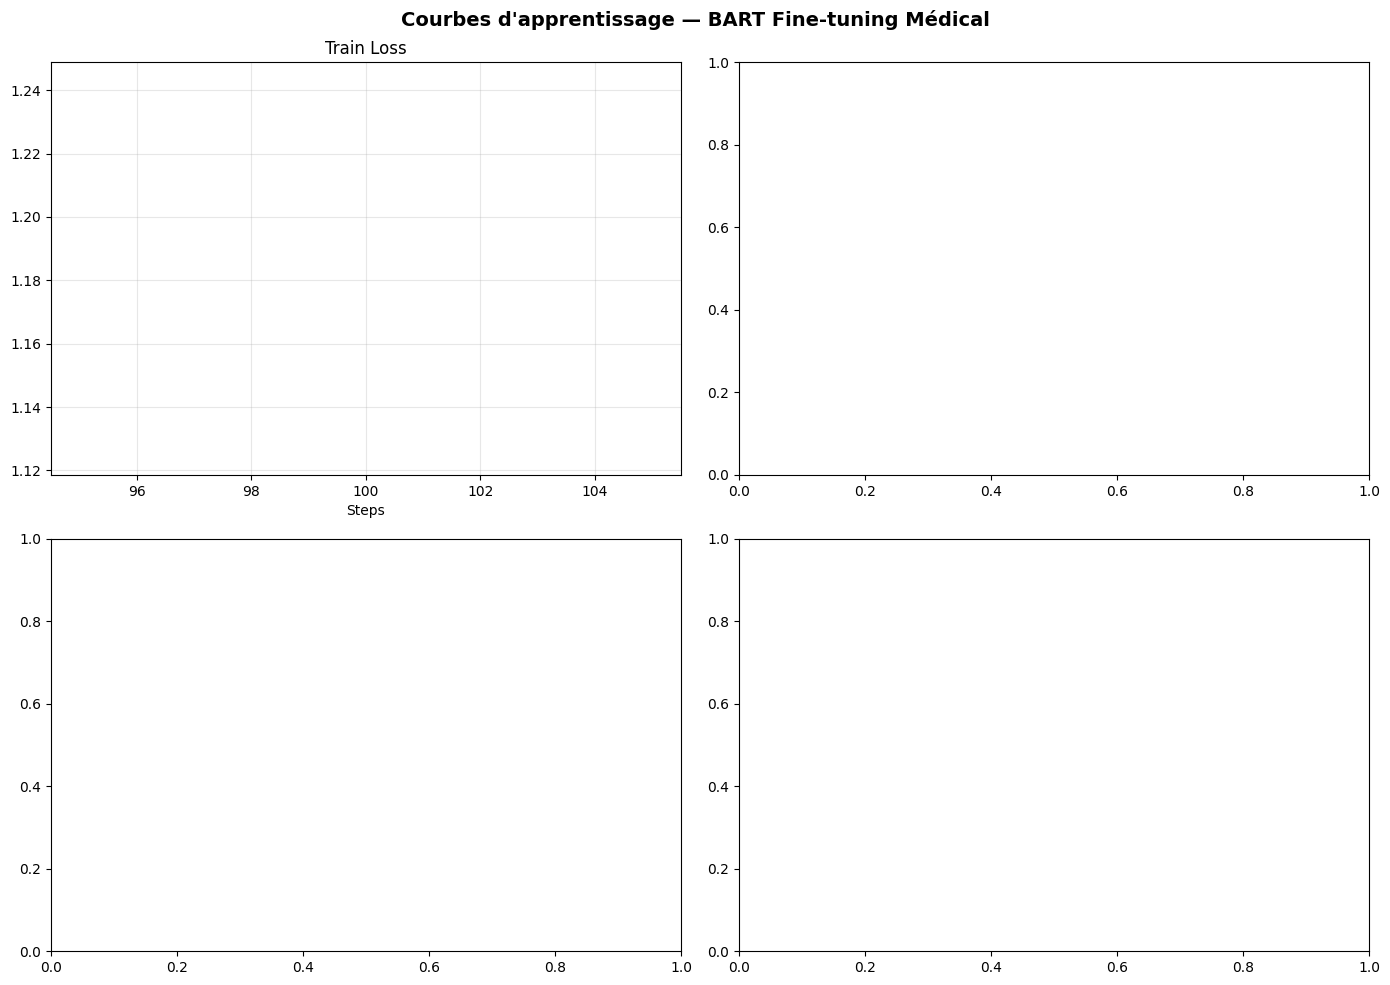

✅ Courbes sauvegardées


In [16]:
# ============================================================
# CELLULE 6 — Visualisation des courbes d'apprentissage
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Extraire l'historique des logs
log_history = trainer.state.log_history

# Séparer train et eval
train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

df_train_log = pd.DataFrame(train_logs)
df_eval_log  = pd.DataFrame(eval_logs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Courbes d'apprentissage — BART Fine-tuning Médical", fontsize=14, fontweight='bold')

# Loss train
axes[0,0].plot(df_train_log['step'], df_train_log['loss'], color='steelblue', alpha=0.7, linewidth=1)
axes[0,0].set_title('Train Loss'); axes[0,0].set_xlabel('Steps'); axes[0,0].grid(alpha=0.3)

# Loss val
if not df_eval_log.empty:
    axes[0,1].plot(df_eval_log['step'], df_eval_log['eval_loss'], color='darkorange', marker='o', ms=4)
    axes[0,1].set_title('Validation Loss'); axes[0,1].set_xlabel('Steps'); axes[0,1].grid(alpha=0.3)

    # ROUGE-L sur val
    if 'eval_rougeL' in df_eval_log.columns:
        axes[1,0].plot(df_eval_log['step'], df_eval_log['eval_rougeL'], color='green', marker='o', ms=4)
        axes[1,0].set_title('ROUGE-L (Validation)'); axes[1,0].set_xlabel('Steps'); axes[1,0].grid(alpha=0.3)

    # ROUGE-1 sur val
    if 'eval_rouge1' in df_eval_log.columns:
        axes[1,1].plot(df_eval_log['step'], df_eval_log['eval_rouge1'], color='crimson', marker='o', ms=4)
        axes[1,1].set_title('ROUGE-1 (Validation)'); axes[1,1].set_xlabel('Steps'); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Courbes sauvegardées')


## Cellule 7 — Évaluation finale sur le set de test

In [17]:
# ============================================================
# CELLULE 7 — Génération sur le set de test
# ============================================================

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from tqdm.notebook import tqdm
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device : {DEVICE}')

print('🔄 Chargement du meilleur modèle...')
model_eval = AutoModelForSeq2SeqLM.from_pretrained(CFG.OUTPUT_DIR).to(DEVICE)
tok_eval   = AutoTokenizer.from_pretrained(CFG.OUTPUT_DIR)
model_eval.eval()
print('✅ Modèle chargé')

def generate_answer(input_text: str) -> str:
    """Génère une réponse pour une paire (question + note)."""
    inputs = tok_eval(
        input_text,
        max_length=CFG.MAX_SOURCE_LEN,
        truncation=True,
        return_tensors='pt'
    ).to(DEVICE)
    with torch.no_grad():
        output_ids = model_eval.generate(
            **inputs,
            max_length           = CFG.GEN_MAX_LEN,
            min_length           = CFG.GEN_MIN_LEN,
            num_beams            = CFG.NUM_BEAMS,
            length_penalty       = CFG.LENGTH_PENALTY,
            no_repeat_ngram_size = CFG.NO_REPEAT_NGRAM,
            early_stopping       = True,
        )
    return tok_eval.decode(output_ids[0], skip_special_tokens=True).strip()

print(f'\n🔄 Génération sur {len(df_test):,} exemples...')
generated = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Génération'):
    try:
        pred = generate_answer(str(row['input_text']))
    except Exception:
        pred = ''
    generated.append(pred)

df_test = df_test.copy()
df_test['generated_answer'] = generated
df_test['reference_answer'] = df_test['target_text'].astype(str)
print('✅ Génération terminée')

# Aperçu
print('\n=== Aperçu 3 exemples ===')
for _, row in df_test.head(3).iterrows():
    print(f'  QUESTION : {str(row[CFG.QUESTION_COL])[:120]}')
    print(f'  RÉFÉRENCE: {row["reference_answer"][:150]}')
    print(f'  GÉNÉRÉ   : {row["generated_answer"][:150]}')
    print()


🖥️  Device : cuda
🔄 Chargement du meilleur modèle...
✅ Modèle chargé

🔄 Génération sur 150 exemples...


Génération:   0%|          | 0/150 [00:00<?, ?it/s]

✅ Génération terminée

=== Aperçu 3 exemples ===
  QUESTION : What is a summary of the hospital course and treatment provided for the patient presented in the discharge summary?
  RÉFÉRENCE: The patient was advised to continue taking low dose aspirin 81 mg orally daily for prevention of venous thromboembolism, which was prescribed as exten
  GÉNÉRÉ   : The patient presented with a left hip intertrochanteric femur fracture secondary to trauma and was diagnosed with factor XII or Hageman factor deficie

  QUESTION : What was the patient's hospital course summary, including key events such as postoperative kidney failure, atrial fibril
  RÉFÉRENCE: The patient's hospital course summary involves postoperative kidney failure, atrial fibrillation, and difficulty with respiratory management leading t
  GÉNÉRÉ   : The patient, a 65-year-old male with a history of kidney transplant, was admitted to the ICU after undergoing thoracic surgery with mitral valve repla

  QUESTION : What were the neo

## Cellule 8 — Calcul des métriques (ROUGE + BERTScore + Compression)

In [18]:
# ============================================================
# CELLULE 8 — Métriques complètes ligne par ligne
# BUG CORRIGÉ : colonnes reference_summary/generated_summary
#   → remplacées par reference_answer/generated_answer
#   (noms définis en cellule 7)
# ============================================================

from rouge_score import rouge_scorer as rouge_lib
from bert_score import score as bertscore_fn
import numpy as np

rouge_sc = rouge_lib.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

# ── ROUGE ligne par ligne ────────────────────────────────
r1, r2, rL = [], [], []
for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='ROUGE'):
    hyp = str(row['generated_answer']).strip()
    ref = str(row['reference_answer']).strip()
    if not hyp or not ref:
        r1.append(0.0); r2.append(0.0); rL.append(0.0)
        continue
    s = rouge_sc.score(ref, hyp)
    r1.append(round(s['rouge1'].fmeasure, 4))
    r2.append(round(s['rouge2'].fmeasure, 4))
    rL.append(round(s['rougeL'].fmeasure, 4))

df_test['rouge1'] = r1
df_test['rouge2'] = r2
df_test['rougeL'] = rL

# ── BERTScore par batches ────────────────────────────────
print('\n🔄 Calcul BERTScore-F1...')
hyps  = df_test['generated_answer'].fillna('').tolist()
refs  = df_test['reference_answer'].fillna('').tolist()
valid = [(i,h,r) for i,(h,r) in enumerate(zip(hyps,refs)) if h.strip() and r.strip()]

bert_f1_col = [0.0] * len(df_test)
if valid:
    idxs  = [x[0] for x in valid]
    vh    = [x[1] for x in valid]
    vr    = [x[2] for x in valid]
    _, _, F1 = bertscore_fn(vh, vr, model_type='distilbert-base-uncased',
                             device=DEVICE, lang='en', verbose=False, batch_size=64)
    for idx, f1 in zip(idxs, F1.cpu().numpy()):
        bert_f1_col[idx] = round(float(f1), 4)

df_test['bertscore_f1'] = bert_f1_col

# ── Compression ──────────────────────────────────────────
# Calcul basé sur la colonne 'note' si disponible, sinon 'input_text'
ref_col_for_compression = CFG.NOTE_COL if CFG.NOTE_COL in df_test.columns else 'input_text'
df_test['src_words']   = df_test[ref_col_for_compression].str.split().str.len()
df_test['gen_words']   = df_test['generated_answer'].str.split().str.len()
df_test['ref_words']   = df_test['reference_answer'].str.split().str.len()
df_test['compression'] = (df_test['gen_words'] / df_test['src_words'].clip(lower=1) * 100).round(2)

# ── Rapport final ────────────────────────────────────────
METRICS = ['rouge1','rouge2','rougeL','bertscore_f1','compression']
print('\n' + '='*55)
print('📊 RÉSULTATS FINAUX — SET DE TEST')
print('='*55)
summary_stats = df_test[METRICS].describe().round(4)
print(summary_stats.to_string())

# Par tâche si disponible
if 'task' in df_test.columns:
    print('\n=== Par type de tâche ===')
    print(df_test.groupby('task')[METRICS].mean().round(4).to_string())

# Sauvegarder
df_test.to_csv(f'{CFG.OUTPUT_DIR}/test_results.csv', index=False)
print(f'\n✅ Résultats sauvegardés : {CFG.OUTPUT_DIR}/test_results.csv')


ROUGE:   0%|          | 0/150 [00:00<?, ?it/s]


🔄 Calcul BERTScore-F1...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


📊 RÉSULTATS FINAUX — SET DE TEST
         rouge1    rouge2    rougeL  bertscore_f1  compression
count  150.0000  150.0000  150.0000      150.0000     150.0000
mean     0.5638    0.3792    0.4595        0.8806      24.7304
std      0.1266    0.1498    0.1434        0.0377       9.0278
min      0.2339    0.0530    0.1569        0.7749       4.6700
25%      0.4786    0.2719    0.3564        0.8554      18.2300
50%      0.5722    0.3793    0.4512        0.8820      22.9450
75%      0.6421    0.4764    0.5573        0.9028      30.0800
max      0.8837    0.7671    0.8267        0.9701      56.1600

=== Par type de tâche ===
               rouge1  rouge2  rougeL  bertscore_f1  compression
task                                                            
Summarization  0.5638  0.3792  0.4595        0.8806      24.7304

✅ Résultats sauvegardés : /kaggle/working/bart_medical/test_results.csv


## Cellule 9 — Visualisations des résultats

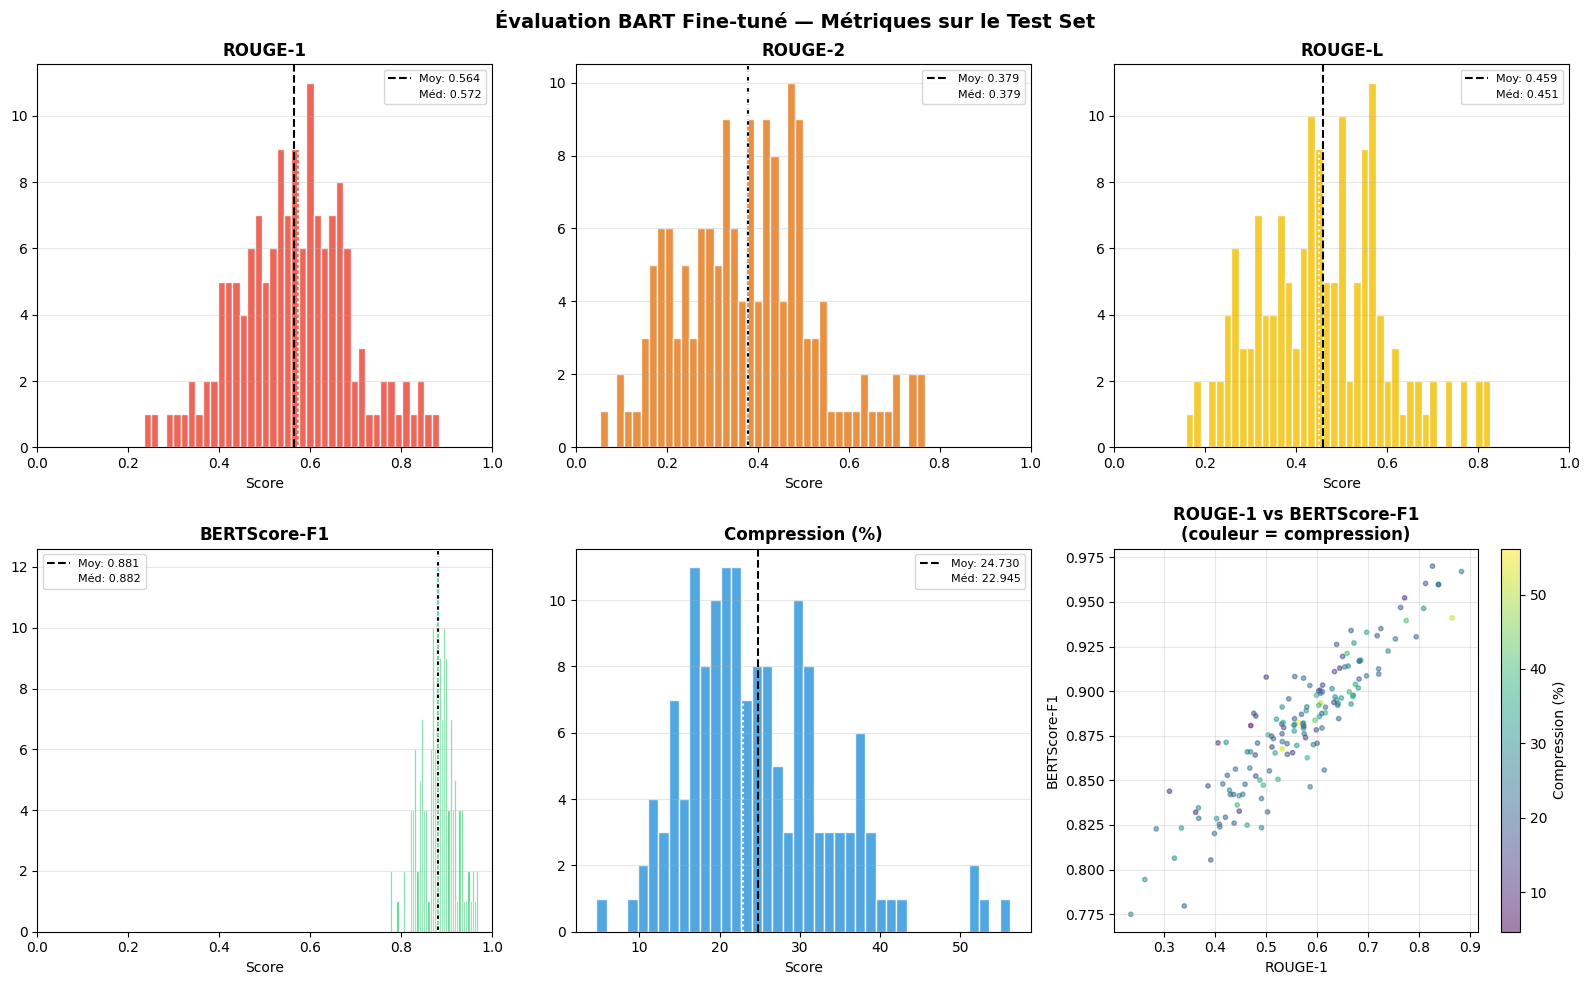


=== Exemples de réponses générées ===

🟢 Meilleurs exemples (ROUGE-L élevé) :
  [R1=0.827 | RL=0.827 | BS=0.970]
  REF  : The patient's response to the CBD+ solution included notable changes in anxiety levels, avoidance behaviors, and sociability, with sustained improvement for two years. No significant side effects or a
  PRED : The patient's response to the CBD+ solution was notable changes in anxiety levels, avoidance behaviors, and sociability, and indicated a therapeutic effect. No significant side effects or adverse even

  [R1=0.884 | RL=0.822 | BS=0.967]
  REF  : The patient underwent neoadjuvant therapy of accelerated hyperfractionated radiation and concurrent ETT for recurrent AS of her right breast. After completing the neoadjuvant therapy, she had a right 
  PRED : The patient was admitted for neoadjuvant therapy consisting of accelerated hyperfractionated radiation and concurrent ETT for recurrent AS of the right breast. She underwent right total mastectomy wit

🔴 Exemple

In [19]:
# ============================================================
# CELLULE 9 — Visualisations complètes
# BUG CORRIGÉ : colonnes reference_summary/generated_summary
#   → reference_answer/generated_answer (cohérent avec cellule 7)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Évaluation BART Fine-tuné — Métriques sur le Test Set', fontsize=14, fontweight='bold')

metrics_cfg = [
    ('rouge1',       'ROUGE-1',         '#E74C3C', (0,1)),
    ('rouge2',       'ROUGE-2',         '#E67E22', (0,1)),
    ('rougeL',       'ROUGE-L',         '#F1C40F', (0,1)),
    ('bertscore_f1', 'BERTScore-F1',    '#2ECC71', (0,1)),
    ('compression',  'Compression (%)', '#3498DB', None),
]

for i, (col, label, color, xlim) in enumerate(metrics_cfg):
    ax = axes[i//3][i%3]
    data = df_test[df_test[col]>0][col]
    ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='white', lw=0.4)
    ax.axvline(data.mean(),   color='black', ls='--', lw=1.5, label=f'Moy: {data.mean():.3f}')
    ax.axvline(data.median(), color='white', ls=':',  lw=1.5, label=f'Méd: {data.median():.3f}')
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Score')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    if xlim: ax.set_xlim(xlim)

# 6ème case : scatter ROUGE-1 vs BERTScore
ax6 = axes[1][2]
sc = ax6.scatter(df_test['rouge1'], df_test['bertscore_f1'],
                 c=df_test['compression'], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, ax=ax6, label='Compression (%)')
ax6.set_xlabel('ROUGE-1'); ax6.set_ylabel('BERTScore-F1')
ax6.set_title('ROUGE-1 vs BERTScore-F1\n(couleur = compression)', fontweight='bold')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/eval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Exemples qualitatifs ─────────────────────────────────
print('\n=== Exemples de réponses générées ===')
sample_good = df_test.nlargest(2, 'rougeL')[['reference_answer','generated_answer','rouge1','rougeL','bertscore_f1']]
sample_bad  = df_test.nsmallest(2, 'rougeL')[['reference_answer','generated_answer','rouge1','rougeL','bertscore_f1']]

print('\n🟢 Meilleurs exemples (ROUGE-L élevé) :')
for _, row in sample_good.iterrows():
    print(f'  [R1={row["rouge1"]:.3f} | RL={row["rougeL"]:.3f} | BS={row["bertscore_f1"]:.3f}]')
    print(f'  REF  : {row["reference_answer"][:200]}')
    print(f'  PRED : {row["generated_answer"][:200]}')
    print()

print('🔴 Exemples difficiles (ROUGE-L faible) :')
for _, row in sample_bad.iterrows():
    print(f'  [R1={row["rouge1"]:.3f} | RL={row["rougeL"]:.3f} | BS={row["bertscore_f1"]:.3f}]')
    print(f'  REF  : {row["reference_answer"][:200]}')
    print(f'  PRED : {row["generated_answer"][:200]}')
    print()
